# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

## 2. Datos

In [2]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df_portatiles = pd.read_csv("./data/train.csv", index_col="laptop_ID")
df_portatiles.index.name=None

### 2.1 Exploración de los datos

In [3]:
df_portatiles.info() #Hay mucho string

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [4]:
df_portatiles.head(5) #Laptop ID --> índice de test csv

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
df_portatiles.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [6]:
#Función de descripción del dataset:
def describe_df(df):
    DATA_TYPE=df.dtypes
    MISSINGS=(df.isna().sum()/len(df)*100).sort_values(ascending=False)
    UNIQUE_VALUES=df.nunique()
    CARDIN=UNIQUE_VALUES/len(df)*100
    describe_df=pd.DataFrame([DATA_TYPE, MISSINGS, UNIQUE_VALUES, CARDIN])
    parametros=["DATA_TYPE", "MISSINGS (%)", "UNIQUE_VALUES", "CARDIN (%)"]
    describe_df.insert(0, "COL_N",parametros)
    return describe_df

In [7]:
describe_df(df_portatiles).T

,0,1,2,3
COL_N,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
Company,object,0.0,19,2.083333
Product,object,0.0,480,52.631579
TypeName,object,0.0,6,0.657895
Inches,float64,0.0,17,1.864035
ScreenResolution,object,0.0,36,3.947368
Cpu,object,0.0,107,11.732456
Ram,object,0.0,9,0.986842
Memory,object,0.0,37,4.057018
Gpu,object,0.0,93,10.197368


In [8]:
for col in df_portatiles.columns:
    print(df_portatiles[col].value_counts(normalize=True)*100)
    print("-------------------------------------------------------")

Company
Lenovo       22.149123
Dell         21.600877
HP           21.271930
Asus         13.267544
Acer          8.114035
MSI           4.057018
Toshiba       3.728070
Apple         1.864035
Razer         0.657895
Mediacom      0.657895
Samsung       0.548246
Microsoft     0.548246
Xiaomi        0.328947
Huawei        0.219298
Chuwi         0.219298
Google        0.219298
Vero          0.219298
Fujitsu       0.219298
LG            0.109649
Name: proportion, dtype: float64
-------------------------------------------------------
Product
XPS 13                                   2.521930
Inspiron 3567                            2.412281
Legion Y520-15IKBN                       1.644737
Vostro 3568                              1.535088
ProBook 450                              1.425439
                                           ...   
Inspiron 7773                            0.109649
ENVY -                                   0.109649
Latitude E7270                           0.109649
Rog GL55

In [9]:
df_portatiles.describe()

,Inches,Price_in_euros
count,912.000000,912.000000
mean,14.981579,1111.724090
std,1.436719,687.959172
min,10.100000,174.000000
25%,14.000000,589.000000
50%,15.600000,978.000000
75%,15.600000,1483.942500
max,18.400000,6099.000000


In [10]:
#Hacemos una copia del dataset:
df=df_portatiles.copy()

### 2.3 Definir X e y

In [11]:
#Nota: considerar cambiar el orden 2.3 <--> 2.4
X = df.drop(['Price_in_euros'], axis=1)
y = df['Price_in_euros'].copy()
X.shape

(912, 11)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [13]:
X_train.columns

Index(['Company', 'Product', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu',
       'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight'],
      dtype='object')

In [14]:
#Eliminamos la columna Product ya que tiene demasiada cardinalidad
X_train.drop(columns=["Product"], inplace=True)
X_test.drop(columns=["Product"], inplace=True)

#Columna RAM: Quitamos "GB" y sustituimos por entero
X_train["Ram"]=X_train["Ram"].str.replace('GB', "").astype(int)
X_test["Ram"]=X_test["Ram"].str.replace("GB","").astype(int)

#Columna weight: quitamos "kg" y lo convertimos a número decimal
X_train["Weight"] = X_train["Weight"].str.replace("kg", "").astype(float)
X_test["Weight"] = X_test["Weight"].str.replace("kg", "").astype(float)



In [15]:
X_train.isna().sum()

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
dtype: int64

In [16]:
#Extraemos los números correspondientes al ancho y alto de la resolución:
resolucion_train = X_train["ScreenResolution"].str.extract(r"(\d+)x(\d+)")
resolucion_test = X_test["ScreenResolution"].str.extract(r"(\d+)x(\d+)")

X_train["X_res"] = resolucion_train[0].astype(int)
X_train["Y_res"] = resolucion_train[1].astype(int)

X_test["X_res"] = resolucion_test[0].astype(int)
X_test["Y_res"] = resolucion_test[1].astype(int)

#Creamos la columna de pixeles 
X_train["Pixels"]=X_train["X_res"] * X_train["Y_res"]
X_test["Pixels"]=X_test["X_res"] * X_test["Y_res"]

#Eliminamos X_res e Y_res:
X_train.drop(columns=["X_res", "Y_res"], inplace=True)
X_test.drop(columns=["X_res", "Y_res"], inplace=True)


In [17]:
X_test.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Pixels'],
      dtype='object')

In [18]:
#Creamos variables binarias para las características extra
#Creamos variable IPS:
X_train['IPS'] = X_train['ScreenResolution'].apply(lambda x: 1 if "IPS" in x else 0)
X_test['IPS'] = X_test['ScreenResolution'].apply(lambda x: 1 if "IPS" in x else 0)
#Creamos variable Touchscreen:
X_train['Touchscreen'] = X_train['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)
X_test['Touchscreen'] = X_test['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

In [19]:
X_train.Cpu.value_counts()

Cpu
Intel Core i5 7200U 2.5GHz       100
Intel Core i7 7700HQ 2.8GHz       82
Intel Core i7 7500U 2.7GHz        77
Intel Core i5 8250U 1.6GHz        46
Intel Core i7 8550U 1.8GHz        40
                                ... 
Intel Core i5 7500U 2.7GHz         1
Intel Core i3 6100U 2.1GHz         1
Intel Core M 1.1GHz                1
Intel Xeon E3-1535M v5 2.9GHz      1
AMD E-Series 6110 1.5GHz           1
Name: count, Length: 93, dtype: int64

In [20]:
#Variable CPU: Extraemos el número que está por delante de "GHz":
X_train["Cpu_GHz"] = X_train["Cpu"].str.extract(r'(\d+\.?\d*)GHz').astype(float)
X_test["Cpu_GHz"] = X_test["Cpu"].str.extract(r'(\d+\.?\d*)GHz').astype(float)

In [21]:
X_train.Cpu_GHz.value_counts()

Cpu_GHz
2.50    156
2.70     95
2.80     94
1.60     92
2.30     49
2.00     47
1.80     44
2.60     36
1.10     30
2.40     27
2.90     12
3.00      7
1.20      7
2.20      6
1.50      6
1.44      6
3.60      4
1.30      4
0.90      3
2.10      2
3.10      1
1.90      1
Name: count, dtype: int64

In [22]:
def procesar_cpu(texto):
    if "Intel Core i7" in texto:
        return "Intel Core i7"
    elif "Intel Core i5" in texto:
        return "Intel Core i5"
    elif 'Intel Core i3' in texto:
        return "Intel Core i3"
    elif "Intel" in texto:
        return "Other Intel Processor" # ejemplo: Celeron
    else:
        return "AMD Processor"

X_train["Cpu_Brand"] = X_train["Cpu"].apply(procesar_cpu)
X_test["Cpu_Brand"] = X_test["Cpu"].apply(procesar_cpu)

In [23]:
X_train.Cpu_Brand.value_counts(normalize=True)

Cpu_Brand
Intel Core i7            0.410151
Intel Core i5            0.318244
Other Intel Processor    0.127572
Intel Core i3            0.101509
AMD Processor            0.042524
Name: proportion, dtype: float64

In [24]:
X_train.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Pixels', 'IPS', 'Touchscreen',
       'Cpu_GHz', 'Cpu_Brand'],
      dtype='object')

In [25]:
X_train.Memory.value_counts(normalize=True)

Memory
256GB SSD                 0.310014
1TB HDD                   0.167353
500GB HDD                 0.109739
512GB SSD                 0.085048
128GB SSD +  1TB HDD      0.076818
128GB SSD                 0.061728
256GB SSD +  1TB HDD      0.058985
32GB Flash Storage        0.031550
1TB SSD                   0.010974
64GB Flash Storage        0.010974
256GB Flash Storage       0.009602
512GB SSD +  1TB HDD      0.008230
256GB SSD +  2TB HDD      0.008230
2TB HDD                   0.008230
16GB Flash Storage        0.005487
128GB Flash Storage       0.005487
1.0TB Hybrid              0.004115
32GB SSD                  0.004115
512GB SSD +  2TB HDD      0.002743
180GB SSD                 0.002743
8GB SSD                   0.001372
1TB SSD +  1TB HDD        0.001372
128GB HDD                 0.001372
240GB SSD                 0.001372
512GB Flash Storage       0.001372
512GB SSD +  512GB SSD    0.001372
1TB HDD +  1TB HDD        0.001372
1.0TB HDD                 0.001372
256GB SSD +  

In [26]:
#Variable Memory:
# Aplicamos los cambios a ambos sets
for df_split in [X_train, X_test]:
    # 1. Limpieza básica y estandarización
    df_split["Memory"] = df_split["Memory"].astype(str).replace("\.0", "", regex=True)
    df_split["Memory"] = df_split["Memory"].str.replace("GB", "")
    df_split["Memory"] = df_split["Memory"].str.replace("TB", "000") # Convertimos TB a GB aproximados

    # 2. Creamos columnas binarias para los tipos más comunes
    df_split["Layer1HDD"] = df_split["Memory"].apply(lambda x: 1 if "HDD" in x else 0)
    df_split["Layer1SSD"] = df_split["Memory"].apply(lambda x: 1 if "SSD" in x else 0)
    
    # 3. Extraemos la cantidad numérica
    # Usamos regex para sacar solo los números antes de cualquier texto
    df_split["Memory_Amount"] = df_split["Memory"].str.extract("(\d+)").astype(float)

# Verificamos el resultado en X_train
X_train[["Memory", "Memory_Amount", "Layer1SSD", "Layer1HDD"]]

<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:5: SyntaxWarning: invalid escape sequence '\.'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aquin\AppData\Local\Temp\ipykernel_668\3979069552.py:5: SyntaxWarning: invalid escape sequence '\.'
  df_split["Memory"] = df_split["Memory"].astype(str).replace("\.0", "", regex=True)
C:\Users\aquin\AppData\Local\Temp\ipykernel_668\3979069552.py:15: SyntaxWarning: invalid escape sequence '\d'
  df_split["Memory_Amount"] = df_split["Memory"].str.extract("(\d+)").astype(float)


,Memory,Memory_Amount,Layer1SSD,Layer1HDD
1118,1000 HDD,1000.0,0,1
153,512 SSD,512.0,1,0
275,512 SSD,512.0,1,0
1100,500 HDD,500.0,0,1
131,256 SSD + 2000 HDD,256.0,1,1
...,...,...,...,...
578,2000 HDD,2000.0,0,1
996,256 SSD,256.0,1,0
770,256 SSD,256.0,1,0
407,1000 HDD,1000.0,0,1


In [27]:
#pd.set_option('display.max_rows', None)
df_portatiles.Gpu.value_counts()

Gpu
Intel HD Graphics 620       185
Intel HD Graphics 520       125
Intel UHD Graphics 620       52
Nvidia GeForce GTX 1050      48
Nvidia GeForce 940MX         31
                           ... 
AMD Radeon RX 540             1
Nvidia Quadro M2000M          1
Nvidia GeForce GTX 940M       1
AMD Radeon R5 520             1
Nvidia GeForce GTX 1070M      1
Name: count, Length: 93, dtype: int64

In [ ]:
describe_df(df_portatiles).T

In [28]:
X_train.Gpu.value_counts(normalize=True)

Gpu
Intel HD Graphics 620      0.205761
Intel HD Graphics 520      0.150892
Intel UHD Graphics 620     0.058985
Nvidia GeForce GTX 1050    0.043896
Nvidia GeForce 940MX       0.032922
                             ...   
Nvidia GeForce GTX 940M    0.001372
Intel HD Graphics 620      0.001372
Intel HD Graphics 5300     0.001372
Nvidia Quadro M2000M       0.001372
AMD R17M-M1-70             0.001372
Name: proportion, Length: 84, dtype: float64

In [29]:
# Aplicamos la extracción de la marca de la GPU:
for df_split in [X_train, X_test]:
    # Extraemos la primera palabra de la columna Gpu, que siempre es la marca
    df_split["Gpu_Brand"] = df_split["Gpu"].apply(lambda x: x.split()[0])
    

#Verificamos que solo tengamos las marcas deseadas
print(X_train["Gpu_Brand"].value_counts())

Gpu_Brand
Intel     417
Nvidia    220
AMD        92
Name: count, dtype: int64


In [30]:
#Reducimos la cardinalidad de la variable OpSys:
def categorizar_os(sistema):
    if "Windows" in sistema:
        return "Windows"
    elif "Mac" in sistema or "macOS" in sistema:
        return "Mac"
    elif "Linux" in sistema:
        return "Linux"
    else:
        return "No OS / Others" # Aquí entran "No OS", "Android", "Chrome OS"

# Aplicamos la función a ambos conjuntos
for df_split in [X_train, X_test]:
    df_split["OpSys_Group"] = df_split["OpSys"].apply(categorizar_os)
    

# Verificamos cómo han quedado las nuevas categorías
print(X_train["OpSys_Group"].value_counts())

OpSys_Group
Windows           625
No OS / Others     54
Linux              37
Mac                13
Name: count, dtype: int64


In [31]:
X_train.columns

Index(['Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram',
       'Memory', 'Gpu', 'OpSys', 'Weight', 'Pixels', 'IPS', 'Touchscreen',
       'Cpu_GHz', 'Cpu_Brand', 'Layer1HDD', 'Layer1SSD', 'Memory_Amount',
       'Gpu_Brand', 'OpSys_Group'],
      dtype='object')

In [32]:
cols_eliminar=["ScreenResolution", "Cpu", "Memory", "Gpu", "OpSys"]
X_train.drop(columns=cols_eliminar, inplace=True)
X_test.drop(columns=cols_eliminar, inplace=True)

In [33]:
describe_df(X_train).T

,0,1,2,3
COL_N,DATA_TYPE,MISSINGS (%),UNIQUE_VALUES,CARDIN (%)
Company,object,0.0,17,2.331962
TypeName,object,0.0,6,0.823045
Inches,float64,0.0,15,2.057613
Ram,int64,0.0,8,1.097394
Weight,float64,0.0,142,19.478738
Pixels,int64,0.0,13,1.783265
IPS,int64,0.0,2,0.274348
Touchscreen,int64,0.0,2,0.274348
Cpu_GHz,float64,0.0,22,3.017833


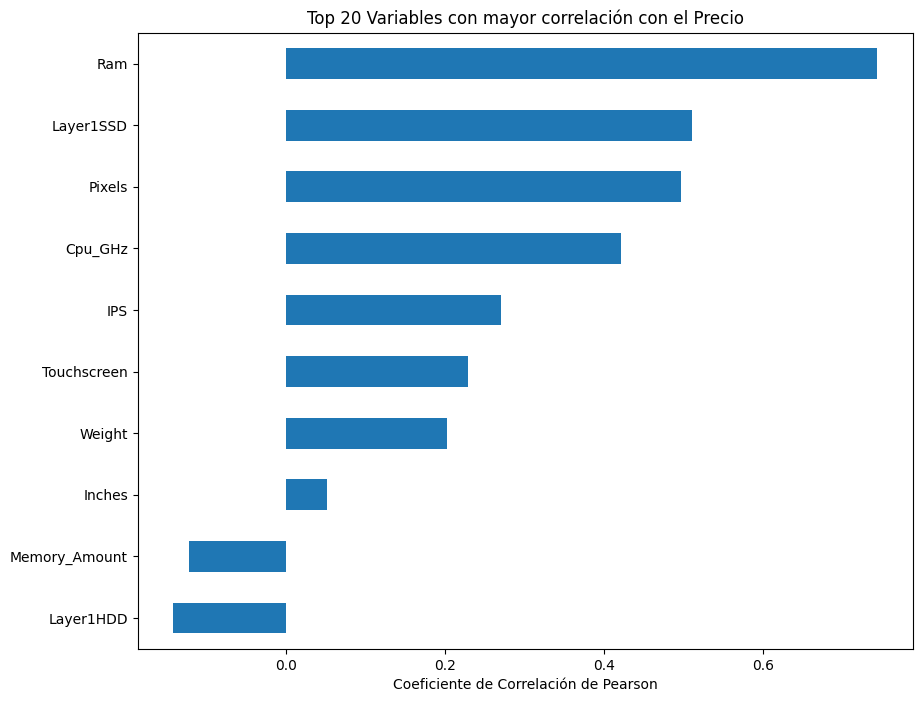

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Unimos temporalmente para calcular la correlación
train_full = X_train.copy()
train_full["Price_in_euros"] = y_train

# 2. Calculamos la correlación de todas las variables con el precio
# Ordenamos de mayor a menor para ver las más importantes arriba
correlations = train_full.corr(numeric_only=True)["Price_in_euros"].sort_values(ascending=False)

# 3. Visualizamos las 20 correlaciones más fuertes (positivas y negativas)
plt.figure(figsize=(10, 8))
correlations.drop("Price_in_euros").head(20).plot(kind="barh")
plt.title("Top 20 Variables con mayor correlación con el Precio")
plt.xlabel("Coeficiente de Correlación de Pearson")
plt.gca().invert_yaxis() # Para que la más alta salga arriba

<Axes: >

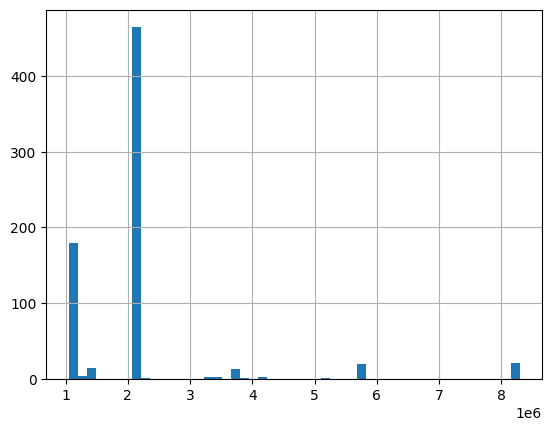

In [36]:
X_train.Pixels.hist(bins=50)

In [37]:
#Importamos las librerias necesarias:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

In [43]:
X_train.Touchscreen.value_counts(normalize=True)

Touchscreen
0    0.865569
1    0.134431
Name: proportion, dtype: float64

In [44]:
#Lista de columnas actualizada
num_log_features = ["Ram", "Memory_Amount", "Pixels"] 
num_features = ["Inches", "Weight", "Cpu_GHz"]
cat_features = ["Company","TypeName", "Cpu_Brand", "Gpu_Brand", "OpSys_Group"]

#Pipelines simplificados (sin SimpleImputer)
cat_pipeline = Pipeline([
    ("OHEncoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False))
])

num_pipeline_log = Pipeline([
    ("Apply_Logarithm", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("SScaler", StandardScaler())
])

num_pipeline = Pipeline([
    ("SScaler", StandardScaler())
])

#ColumnTransformer
preprocessing = ColumnTransformer([
    ("Process_Numeric_Log", num_pipeline_log, num_log_features),
    ("Process_Numeric", num_pipeline, num_features),
    ("Process_Categorical", cat_pipeline, cat_features)
], remainder="passthrough")

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

### 4.1 Baseline de modelos


In [45]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, GridSearchCV

# Pipelines individuales
ridge_pipe = Pipeline([
    ("Preprocesado", preprocessing),
    ("Modelo", Ridge())
])

rf_pipe = Pipeline([
    ("Preprocesado", preprocessing),
    ("Modelo", RandomForestRegressor(random_state=42))
])

xgb_pipe = Pipeline([
    ("Preprocesado", preprocessing),
    ("Modelo", XGBRegressor(random_state=42))
])




### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

In [46]:
#Evaluación rápida con Cross Validation (usando RMSE)
for name, pipe in zip(["Ridge", "RandomForest", "Xgboost"], 
                     [ridge_pipe, rf_pipe, xgb_pipe]):
    resultado = cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    print(f"{name}: {-np.mean(resultado):.4f} {resultado}")


c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Ridge: 356.4580 [-343.94931799 -322.18759057 -344.77750797 -324.38849629 -446.98719892]


c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


RandomForest: 294.3436 [-285.73724717 -244.04242259 -254.57113932 -261.31817022 -426.0491754 ]


c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Xgboost: 313.3812 [-266.64344787 -279.87831317 -303.95179701 -260.91169399 -455.52052767]


### 4.3 Optimización (up to you 🫰🏻)

In [47]:
#Definición de hiperparámetros:
param_ridge = {
    "Modelo__alpha": [0.1, 1.0, 10.0]
}

param_rf = {
    "Modelo__n_estimators": [100, 200],
    "Modelo__max_depth": [None, 10, 20],
    "Modelo__max_features": ["sqrt", None]
}

param_xgb = {
    "Modelo__n_estimators": [100, 150, 300, 500, 700],
    "Modelo__learning_rate": [0.02, 0.05, 0.1],
    "Modelo__max_depth": [2,3,4,5],
    "Modelo__subsample": [0.7, 0.8]
}

In [48]:
#Inicialización de los GridSearch
cv = 5
scoring_metric = "neg_root_mean_squared_error"

gs_ridge = GridSearchCV(ridge_pipe, param_ridge, cv=cv, scoring=scoring_metric, n_jobs=-1)
gs_rf = GridSearchCV(rf_pipe, param_rf, cv=cv, scoring=scoring_metric, n_jobs=-1)
gs_xgb = GridSearchCV(xgb_pipe, param_xgb, cv=cv, scoring=scoring_metric, n_jobs=-1, verbose=1)

# 4. Ejecución y resultados
pipe_grids = {
    "Ridge": gs_ridge,
    "RandomForest": gs_rf,
    "XGBoost": gs_xgb
}

In [49]:
best_models ={}

for name, gs in pipe_grids.items():
    print(f"Entrenando GridSearch para {name}...")
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    print(f"Mejor R2 en CV para {name}: {gs.best_score_:.4f}")
    print(f"Mejores parámetros: {gs.best_params_}\n")

Entrenando GridSearch para Ridge...
Mejor R2 en CV para Ridge: -355.8704
Mejores parámetros: {'Modelo__alpha': 0.1}

Entrenando GridSearch para RandomForest...
Mejor R2 en CV para RandomForest: -288.9250
Mejores parámetros: {'Modelo__max_depth': None, 'Modelo__max_features': 'sqrt', 'Modelo__n_estimators': 200}

Entrenando GridSearch para XGBoost...
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Mejor R2 en CV para XGBoost: -271.3481
Mejores parámetros: {'Modelo__learning_rate': 0.05, 'Modelo__max_depth': 3, 'Modelo__n_estimators': 700, 'Modelo__subsample': 0.7}



In [50]:
best_model = gs_xgb.best_estimator_

-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [51]:
#RECORDAR HACER LAS MISMAS TRANSFORMACIONES

In [52]:
X_pred = pd.read_csv("./data/test.csv",index_col="laptop_ID")
df.index.name=None #establecer mejor laptop_id como indice
X_pred.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [53]:
X_pred.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [54]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 209 to 421
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           391 non-null    object 
 1   Product           391 non-null    object 
 2   TypeName          391 non-null    object 
 3   Inches            391 non-null    float64
 4   ScreenResolution  391 non-null    object 
 5   Cpu               391 non-null    object 
 6   Ram               391 non-null    object 
 7   Memory            391 non-null    object 
 8   Gpu               391 non-null    object 
 9   OpSys             391 non-null    object 
 10  Weight            391 non-null    object 
dtypes: float64(1), object(10)
memory usage: 36.7+ KB


 ## 2. Replicar el procesado para ``test.csv``

In [55]:
#Eliminamos la columna Product ya que tiene demasiada cardinalidad
X_pred.drop(columns=["Product"], inplace=True)

#Columna RAM: Quitamos "GB" y sustituimos por entero
X_pred["Ram"]=X_pred["Ram"].str.replace('GB', "").astype(int)

#Columna weight: quitamos "kg" y lo convertimos a número decimal
X_pred["Weight"] = X_pred["Weight"].str.replace("kg", "").astype(float)


In [56]:
#Extraemos los números correspondientes al ancho y alto de la resolución:
resolucion_pred = X_pred["ScreenResolution"].str.extract(r"(\d+)x(\d+)")

X_pred["X_res"] = resolucion_pred[0].astype(int)
X_pred["Y_res"] = resolucion_pred[1].astype(int)

#Creamos la columna de pixeles 
X_pred["Pixels"]=X_pred["X_res"] * X_pred["Y_res"]

#Eliminamos X_res e Y_res:
X_pred.drop(columns=["X_res", "Y_res"], inplace=True)


In [57]:
#Creamos variables binarias para las características extra
X_pred['IPS'] = X_pred['ScreenResolution'].apply(lambda x: 1 if "IPS" in x else 0)
X_pred['Touchscreen'] = X_pred['ScreenResolution'].apply(lambda x: 1 if 'Touchscreen' in x else 0)

In [58]:
#Variable CPU: Extraemos el número que está por delante de "GHz":
X_pred["Cpu_GHz"] = X_pred["Cpu"].str.extract(r'(\d+\.?\d*)GHz').astype(float)

In [59]:
#Creamos Cpu_brand
X_pred["Cpu_Brand"] = X_pred["Cpu"].apply(procesar_cpu)

In [60]:
#Variable Memory:
# Aplicamos los cambios a ambos sets
    # 1. Limpieza básica y estandarización
X_pred["Memory"] = X_pred["Memory"].astype(str).replace("\.0", "", regex=True)
X_pred["Memory"] = X_pred["Memory"].str.replace("GB", "")
X_pred["Memory"] = X_pred["Memory"].str.replace("TB", "000") # Convertimos TB a GB aproximados

    # 2. Creamos columnas binarias para los tipos más comunes
X_pred["Layer1HDD"] = X_pred["Memory"].apply(lambda x: 1 if "HDD" in x else 0)
X_pred["Layer1SSD"] = X_pred["Memory"].apply(lambda x: 1 if "SSD" in x else 0)
    
# 3. Extraemos la cantidad numérica
# Usamos regex para sacar solo los números antes de cualquier texto
X_pred["Memory_Amount"] = X_pred["Memory"].str.extract("(\d+)").astype(float)

# Verificamos el resultado en X_train
print(X_pred[["Memory", "Memory_Amount", "Layer1SSD", "Layer1HDD"]].head())

             Memory  Memory_Amount  Layer1SSD  Layer1HDD
laptop_ID                                               
209         512 SSD          512.0          1          0
1281        500 HDD          500.0          0          1
1168       1000 HDD         1000.0          0          1
1231        256 SSD          256.0          1          0
1020        256 SSD          256.0          1          0


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:14: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aquin\AppData\Local\Temp\ipykernel_668\367404850.py:4: SyntaxWarning: invalid escape sequence '\.'
  X_pred["Memory"] = X_pred["Memory"].astype(str).replace("\.0", "", regex=True)
C:\Users\aquin\AppData\Local\Temp\ipykernel_668\367404850.py:14: SyntaxWarning: invalid escape sequence '\d'
  X_pred["Memory_Amount"] = X_pred["Memory"].str.extract("(\d+)").astype(float)


In [61]:
#Creamos variable Gpu_Brand
X_pred["Gpu_Brand"] = X_pred["Gpu"].apply(lambda x: x.split()[0])

In [62]:
#Reducimos la cardinalidad de la variable OpSys:
X_pred["OpSys_Group"] = X_pred["OpSys"].apply(categorizar_os)

In [63]:
#Eliminamos columnas que no necesitamos:
cols_eliminar=["ScreenResolution", "Cpu", "Memory", "Gpu", "OpSys"]
X_pred.drop(columns=cols_eliminar, inplace=True)

In [64]:
X_test.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Pixels', 'IPS',
       'Touchscreen', 'Cpu_GHz', 'Cpu_Brand', 'Layer1HDD', 'Layer1SSD',
       'Memory_Amount', 'Gpu_Brand', 'OpSys_Group'],
      dtype='object')

In [65]:
X_pred.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Pixels', 'IPS',
       'Touchscreen', 'Cpu_GHz', 'Cpu_Brand', 'Layer1HDD', 'Layer1SSD',
       'Memory_Amount', 'Gpu_Brand', 'OpSys_Group'],
      dtype='object')

**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [66]:
# ¿Qué opináis? Si hay que hacerlo
# ¿Sí, no?

In [67]:
X_test.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Pixels', 'IPS',
       'Touchscreen', 'Cpu_GHz', 'Cpu_Brand', 'Layer1HDD', 'Layer1SSD',
       'Memory_Amount', 'Gpu_Brand', 'OpSys_Group'],
      dtype='object')

In [68]:
X_pred.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Pixels', 'IPS',
       'Touchscreen', 'Cpu_GHz', 'Cpu_Brand', 'Layer1HDD', 'Layer1SSD',
       'Memory_Amount', 'Gpu_Brand', 'OpSys_Group'],
      dtype='object')

In [69]:
predicciones = best_model.predict(X_pred)

c:\Users\aquin\Desktop\Bootcamp_DS\DS-Online_AQR\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [70]:
pd.DataFrame(predicciones)

,0
0,1349.321045
1,308.124054
2,370.041809
3,925.299194
4,1022.880005
...,...
386,2121.247070
387,1058.453491
388,1792.012451
389,905.071472


![wow.jpeg](attachment:wow.jpeg)

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [71]:
sample = pd.read_csv("data/sample_submission.csv") #ïndice laptop ID

In [72]:
sample #Formato que hay que subir

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6
...,...,...
386,820,474.3
387,948,1468.8
388,483,520.4
389,1017,515.1


In [73]:
sample.head()

,laptop_ID,Price_in_euros
0,209,1949.1
1,1281,805.0
2,1168,1101.0
3,1231,1293.8
4,1020,1832.6


In [74]:
sample.shape

(391, 2)

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [75]:
#¿Cómo creamos la submission?
submission = pd.DataFrame({"laptop_ID": X_pred.index , "Price_in_euros" : predicciones})

In [76]:
submission.head()

,laptop_ID,Price_in_euros
0,209,1349.321045
1,1281,308.124054
2,1168,370.041809
3,1231,925.299194
4,1020,1022.880005


In [77]:
submission.shape

(391, 2)

In [78]:
X_train.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Pixels', 'IPS',
       'Touchscreen', 'Cpu_GHz', 'Cpu_Brand', 'Layer1HDD', 'Layer1SSD',
       'Memory_Amount', 'Gpu_Brand', 'OpSys_Group'],
      dtype='object')

In [79]:
X_pred.columns

Index(['Company', 'TypeName', 'Inches', 'Ram', 'Weight', 'Pixels', 'IPS',
       'Touchscreen', 'Cpu_GHz', 'Cpu_Brand', 'Layer1HDD', 'Layer1SSD',
       'Memory_Amount', 'Gpu_Brand', 'OpSys_Group'],
      dtype='object')

In [80]:
submission.to_csv("submission_final.csv", index=False)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [81]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [82]:
chequeador(submission)

You're ready to submit!
